# Implementation of Linear and Non-Linear Regression
## Predictive Modelling: CE-I 
### Name: Ajinkya Dattatray Shinde
### Roll No.: 256205
### Course: CSC-554

## Aim
#### To implement Linear and Non-Linear Regression algorithms and visualize best-fit curves using Python.

#### Linear Regression

Linear Regression is a supervised learning algorithm used to model the relationship between Temperature and ice-cream profit using a straight-line equation.
It assumes that marks increase proportionally with an increase in study time.

Linear Regression Formula
Ice-cream profit = m × (Temperature) + c

Where:

Ice-cream profit (y) → Dependent variable (output)

Temperature (x) → Independent variable (input)

m → Slope representing improvement in Ice-cream profit per additional Temperature

c → Intercept representing predicted Ice-cream profit when Temperature is zero

The algorithm finds the best-fit line that minimizes the difference between actual Ice-cream profit and predicted Ice-cream profit.

#### Non-Linear Regression

Non-Linear Regression is used when the relationship between Temperature and Ice Cream Profits does follow a straight line.

In real-life scenarios, Ice Cream Profits may increase rapidly initially and then gradually stabilize due to learning limits or fatigue. Such relationships are better represented using curved equations like polynomial regression.

Example:
Ice Cream Profits = a(Temperature)**2 + b(Temperature) + c

Non-linear regression captures complex learning patterns where performance improvement is not constant.

## 1. Linear Regression

#### Starting with importing the required libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('Ice Cream Sales - temperatures.csv')
data.head()

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


We have features as `Temperature(Degree in Fahrenheit)` and `Ice Cream Profits(In Dollars)`, for further analysis we would consider `Temperature` (being the independent variable) and `Ice Cream Profits` (being the targeted / dependented variable)

In [67]:
# Here we take time_study (independent variable) as X
X = np.array(data['Temperature'])
# Here we take Marks as the target/dependent variable as Y
Y = np.array(data['Ice Cream Profits'])

Calculating the `slope` and the `intercept`, we get,

In [68]:
n = len(X)

# ---- Linear Regression ----
m = (n*np.sum(X*Y) - np.sum(X)*np.sum(Y)) / (n*np.sum(X**2) - (np.sum(X))**2)
c = (np.sum(Y) - m*np.sum(X)) / n

print("Slope:", m)
print("Intercept:", c)
print(f"The Regression Equation is: Y_pred = {round(m,2)}*X + {round(c,2)}")

# Prediction
Y_pred = m*X + c

Slope: 1.1460639215345083
Intercept: -31.2258909638348
The Regression Equation is: Y_pred = 1.15*X + -31.23


Calculating the Total Sum of Squares `SSToT`

In [69]:
# Total Sum of Squares
Y_mean = np.mean(Y)
SSToT = np.sum((Y - Y_mean)**2)
print(f"The Total Sum of Squares is: {SSToT}")

The Total Sum of Squares is: 7057.722328971963


Calculating the Residual Sum of Squares `SSRes`

In [70]:
# Residual Sum of Squares
SSRes = np.sum((Y - Y_pred)**2)
print(f"The Residual Sum of Squares is: {SSRes}")

The Residual Sum of Squares is: 567.228911697009


Calculating the Coefficient of Determinination `R^2`

In [71]:
R2 = 1 - (SSRes/SSToT)
print("Coefficient of Determination R^2 is:", R2)

Coefficient of Determination R^2 is: 0.9196300328551418


Calculating the Standard Error `SE`

In [72]:
SE = np.sqrt(SSRes/(n-2))
print("Standard Error:", SE)

Standard Error: 2.324259045674575


#### Linear regression graph

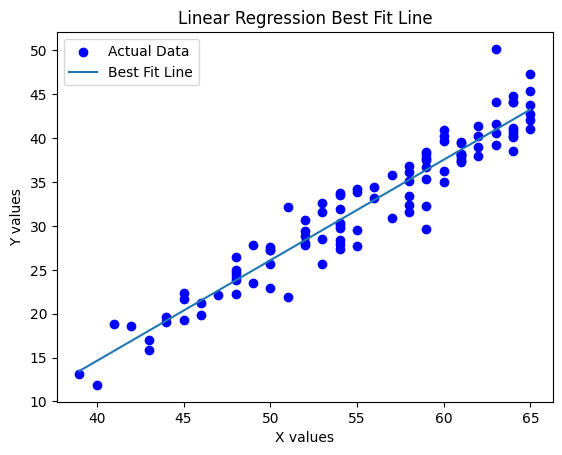

In [73]:
plt.scatter(X, Y, color='blue', label="Actual Data")
plt.plot(X, Y_pred, label="Best Fit Line")

plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Linear Regression Best Fit Line")
plt.legend()
plt.show()

## 2. Non - linear Regression

Using the numpy inbuilt functions

In [74]:
coeff = np.polyfit(X, Y, 2)
poly_model = np.poly1d(coeff)

Y_poly_pred = poly_model(X)

print("Polynomial Equation:")
print(poly_model)

Polynomial Equation:
          2
0.001917 x + 0.9391 x - 25.74


Calculating the polynomial or getting it through the normal equations and then getting the coefficient values by solving the linear equations simultaneously

In [75]:
Sx = np.sum(X)
Sx2 = np.sum(X**2)
Sx3 = np.sum(X**3)
Sx4 = np.sum(X**4)

Sy = np.sum(Y)
Sxy = np.sum(X*Y)
Sx2y = np.sum((X**2)*Y)

# Coefficient matrix
A = np.array([
    [n, Sx, Sx2],
    [Sx, Sx2, Sx3],
    [Sx2, Sx3, Sx4]
])

B = np.array([Sy, Sxy, Sx2y])

# Solve equations
a, b, c = np.linalg.solve(A, B)

print("a =", a)
print("b =", b)
print("c =", c)

print(f"The Second Degree Equation is: {round(a,2)} + {round(b,2)}*x + {round(c,2)}*x^2")

a = -25.73538019851613
b = 0.9391223039337928
c = 0.001917231892328185
The Second Degree Equation is: -25.74 + 0.94*x + 0.0*x^2


#### Non-linear regression graph

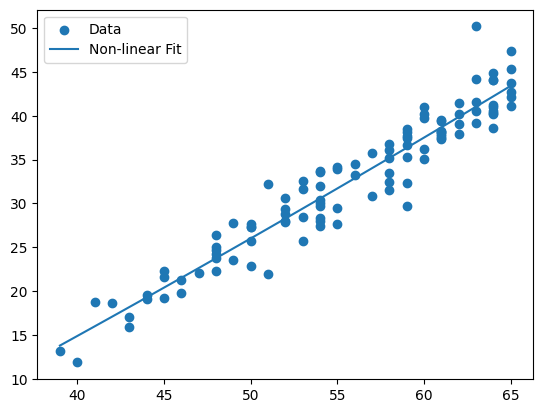

In [76]:
import matplotlib.pyplot as plt

x_range = np.linspace(min(X), max(X),100)
y_curve = a + b*x_range + c*x_range**2

plt.scatter(X,Y,label="Data")
plt.plot(x_range,y_curve,label="Non-linear Fit")

plt.legend()
plt.show()